Reference: https://guides.codepath.com/compsci/UMPIRE-Interview-Strategy

## **1. Understand (U - Understand what the instructor is asking for by using test cases and questions about the problem)**

### What is the project asking?

We're tasked with building a **multi-class classifier** that uses **transfer learning** to identify 9 types of waste from images. We're expected to:

* Split images into training, validation, and test sets
* Preprocess and augment images
* Use **pre-trained CNNs** (ResNet50, ResNet100, EfficientNetB0, VGG16)
* Freeze base layers and train new classification heads
* Train for at least 50 epochs, using early stopping
* Evaluate models using **Precision, Recall, F1 Score, AUC**

### Test Cases / Questions:

* Does the input preprocessing pipeline ensure all images are the same shape?
* Are we freezing the base model correctly?
* Is the model learning meaningful class differences, or just overfitting?
* Can it generalize well on unseen waste images?

---

## **2. Match (M - Match what this problem looks like to known categories of problems, e.g. Linked List or Dynamic Programming and strategies or patterns in those categories)**

### What type of problem is this?

This is a **Supervised Multi-class Image Classification** problem using:

* **Transfer Learning**: for better feature extraction from small datasets
* **CNN Architectures**: pre-trained on ImageNet
* **Evaluation via Classification Metrics** (macro/micro/weighted)

### Related strategies:

* **Data augmentation** to combat overfitting
* **Model checkpointing and early stopping** for generalization
* **Softmax + cross-entropy loss** for multi-class output
* **One-hot encoding** for categorical targets
* **Train/val/test split by class** to ensure balance

---

## **3. Plan (P - Plan the solution with appropriate visualizations and pseudocode)**

### Visual Steps:

1. **Load and label data**
   Each folder → one class → label index → one-hot vector

2. **Split data**
   For each class folder:

   * 80% for training
   * 20% for test
   * 20% of training → validation

3. **Resize/preprocess images**
   Resize to 224×224 (or required shape)

4. **Augment training data**
   Use zoom, flip, rotate, translate, contrast

5. **Load pre-trained model (frozen)**
   Use `include_top=False`
   Add new head:

   ```
   GlobalAveragePooling2D
   Dense → ReLU
   BatchNorm → Dropout(0.2)
   Dense(9, activation='softmax')
   ```

6. **Compile and Train**

   * `categorical_crossentropy`
   * `Adam`, learning rate tuning
   * batch\_size=5
   * 50–100 epochs
   * early stopping on validation loss

7. **Evaluate and Compare**

   * Use sklearn metrics on test set
   * Plot training/val curves
   * Identify best-performing model

### Pseudocode:

```python
for folder in realwaste:
    label = folder_name_to_index[folder]
    for i, img in enumerate(sorted(images_in_folder)):
        image = preprocess(img)
        if i < 0.8 * len(images): train.append((image, label))
        else: test.append((image, label))

augment_train_set()

for model_name in ['ResNet50', 'ResNet100', ...]:
    base_model = load_pretrained(model_name, include_top=False, weights='imagenet')
    freeze_all_layers(base_model)
    head = create_custom_head()
    model = combine(base_model, head)
    compile(model)
    train(model)
    evaluate(model, test_set)
```

---

## **4. Implement (I - Implement the code to solve the algorithm)**

To be conducted

---

## **5. Review (R - Review the code by running specific example(s) and recording values (watchlist) of our code's variables along the way)**

We'll review by:

* Tracking `loss`, `accuracy`, `val_loss`, and `val_accuracy` during training
* Watching example predictions and confusion matrix to check for class confusion
* Logging model performance for each architecture

Tools: `matplotlib`, `sklearn.metrics`, `confusion_matrix`, `classification_report`

---

## **6. Evaluate (E - Evaluate the performance of our algorithm and state any strong/weak or future potential work)**

### Performance Considerations:

* Training time may differ across architectures
* ResNet50 is often a strong baseline; EfficientNetB0 balances speed and performance
* Watch for **overfitting** if val loss diverges from train loss

In [1]:
!pip install tensorflow opencv-python
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, ResNet101, VGG16, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os


# Update this path to where the file lives in Drive
zip_path = "/content/drive/MyDrive/RealWaste.zip"
extract_path = "/content/RealWaste"


# Only unzip if not already extracted
if not os.path.exists(extract_path):
   with zipfile.ZipFile(zip_path, 'r') as zip_ref:
       zip_ref.extractall(extract_path)


print("Unzipped successfully to:", extract_path)

Unzipped successfully to: /content/RealWaste


## Data Exploration and Pre-processing

In [4]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define image size and class names
IMG_SIZE = 160
data_dir = "RealWaste"
class_names = sorted(os.listdir(data_dir))
label_map = {name: idx for idx, name in enumerate(class_names)}
print(label_map)

{'1-Cardboard': 0, '2-Food Organics': 1, '3-Glass': 2, '4-Metal': 3, '5-Miscellaneous Trash': 4, '6-Paper': 5, '7-Plastic': 6, '8-Textile Trash': 7, '9-Vegetation': 8}


In [5]:
# In case all the images do not have the same size, zero-pad or resize the images
# in your dataset. This can be done using various tools, including OpenCV

X = []
y = []

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    image_files = sorted(os.listdir(class_path))

    for file in image_files:
        img_path = os.path.join(class_path, file)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label_map[class_name])
        except:
            print(f"Skipping unreadable file: {img_path}")

In [6]:
# Images are numbered in each folder. Select the first 80% of the images in
# each folder as your training set and the rest as the test set. You can encode
# your classes using one-hot encoding.

from tensorflow.keras.applications.resnet import preprocess_input


X = np.array(X, dtype=np.float32)
X = preprocess_input(X)
y = to_categorical(y, num_classes=9)  # one-hot encode
print(X.shape, y.shape)

# Create non-one-hot label array for stratification
y_labels = np.argmax(y, axis=1)

# 80% train, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_labels, random_state=42
)

# Use same strategy to split validation from training
y_train_full_labels = np.argmax(y_train_full, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full_labels, random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_val.shape)
print("Test:", X_test.shape)

(4752, 160, 160, 3) (4752, 9)
Train: (3040, 160, 160, 3)
Valid: (761, 160, 160, 3)
Test: (951, 160, 160, 3)


## Transfer Learning

In [7]:
# In this project, you will use pre-trained models ResNet50, ResNet100,
# EfficientNetB0, and VGG16. For those pre-trained networks, you will only
# train the last fully connected layer, and will freeze all layers before them
# (i.e. we do not change their parameters during training) and use the outputs
# of the penultimate layer in the original pre-trained model as the features
# extracted from each image.
# ------------------------------------------------------------------------------
# Use ReLU activation functions in the last layer and a softmax layer, along
# with L₂ regularization, batch normalization, and a dropout rate of 20% as well
# as ADAM optimizer. Use multinomial cross entropy loss. You can try any batch
# size, but a batch size of 5 seems reasonable.

from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam


def build_model(input_shape=(160, 160, 3), num_classes=9):
   base_model = ResNet50(include_top=False, weights="imagenet", input_shape=input_shape)
   base_model.trainable = False  # Freeze all layers


   inputs = Input(shape=input_shape)
   x = base_model(inputs, training=False)  # Feature extraction from penultimate layer
   x = GlobalAveragePooling2D()(x)
  # x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)  # Fully connected head
   x = BatchNormalization()(x)
   x = Dropout(0.2)(x)
   outputs = Dense(num_classes, activation='softmax')(x)


   model = Model(inputs, outputs)
   model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
   return model



In [8]:
# To perform empirical regularization, crop, randomly zoom, rotate, flip,
# contrast, and translate images in your training set for image augmentation.
# You can use various tools to do this, including OpenCV.

train_aug = ImageDataGenerator(
   rotation_range=30,
   zoom_range=0.3,
   width_shift_range=0.2,
   height_shift_range=0.2,
   horizontal_flip=True,
   brightness_range=[0.7, 1.3]
)

val_aug = ImageDataGenerator()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3939 - loss: 1.9034

203/203 ━━━━━━━━━━━━━━━━━━━━ 54s 199ms/step - accuracy: 0.3945 - loss: 1.9014 - val_accuracy: 0.6597 - val_loss: 1.0594
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6478 - loss: 1.0789

203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6478 - loss: 1.0787 - val_accuracy: 0.7070 - val_loss: 0.9807
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6916 - loss: 0.9425

...

203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7238 - loss: 0.7971 - val_accuracy: 0.7582 - val_loss: 0.8200
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7432 - loss: 0.7853

203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 145ms/step - accuracy: 0.7432 - loss: 0.7852 - val_accuracy: 0.7661 - val_loss: 0.7754
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - accuracy: 0.7442 - loss: 0.7460 - val_accuracy: 0.7727 - val_loss: 0.7826
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.7681 - loss: 0.6845 - val_accuracy: 0.7411 - val_loss: 0.9181
Epoch 9/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.7744 - loss: 0.6665 - val_accuracy: 0.7530 - val_loss: 0.8878
Epoch 10/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.7580 - loss: 0.7362 - val_accuracy: 0.7569 - val_loss: 0.8705
Epoch 11/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7748 - loss: 0.6749 - val_accuracy: 0.7503 - val_loss: 0.9134
Epoch 12/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7803 - loss: 0.6081 - val_accuracy: 0.7543 - val_loss: 0.8544
Epoch 13/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7632 - loss: 0

203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.7699 - loss: 0.6886 - val_accuracy: 0.7766 - val_loss: 0.7663
Epoch 16/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7931 - loss: 0.6211 - val_accuracy: 0.7700 - val_loss: 0.8272
Epoch 17/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.8028 - loss: 0.6036 - val_accuracy: 0.7687 - val_loss: 0.8321
Epoch 18/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.7803 - loss: 0.6414 - val_accuracy: 0.7556 - val_loss: 0.8998
Epoch 19/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7840 - loss: 0.6640 - val_accuracy: 0.7714 - val_loss: 0.8100
Epoch 20/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.7876 - loss: 0.6354 - val_accuracy: 0.7543 - val_loss: 0.9252
Epoch 21/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.7807 - loss: 0.6661 - val_accuracy: 0.7740 - val_loss: 0.8194
Epoch 22/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.8015 - loss

203/203 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.8152 - loss: 0.5960 - val_accuracy: 0.7963 - val_loss: 0.7476
Epoch 75/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8143 - loss: 0.5873

203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.8142 - loss: 0.5874 - val_accuracy: 0.7963 - val_loss: 0.7439
Epoch 76/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.8000 - loss: 0.6108 - val_accuracy: 0.7871 - val_loss: 0.7812
Epoch 77/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.7914 - loss: 0.6866 - val_accuracy: 0.7543 - val_loss: 0.9435
Epoch 78/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.8056 - loss: 0.5783 - val_accuracy: 0.7792 - val_loss: 0.8318
Epoch 79/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.7975 - loss: 0.6138 - val_accuracy: 0.7608 - val_loss: 0.8982
Epoch 80/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.8030 - loss: 0.6113 - val_accuracy: 0.7674 - val_loss: 0.8746
Epoch 81/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.8060 - loss: 0.6190 - val_accuracy: 0.7792 - val_loss: 0.8058
Epoch 82/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.7901 - loss

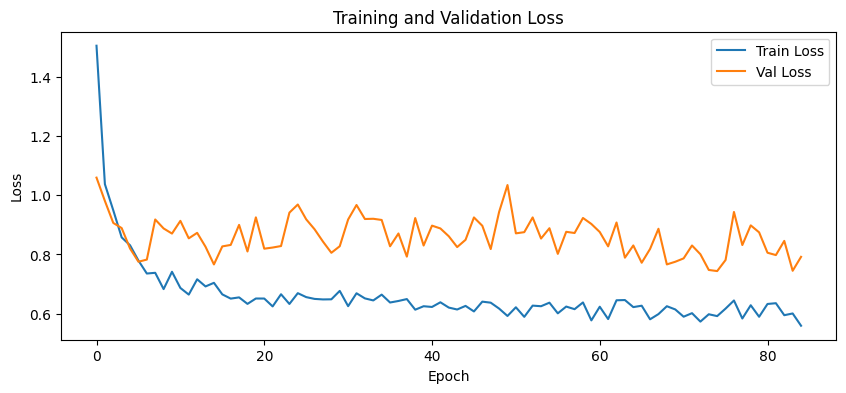

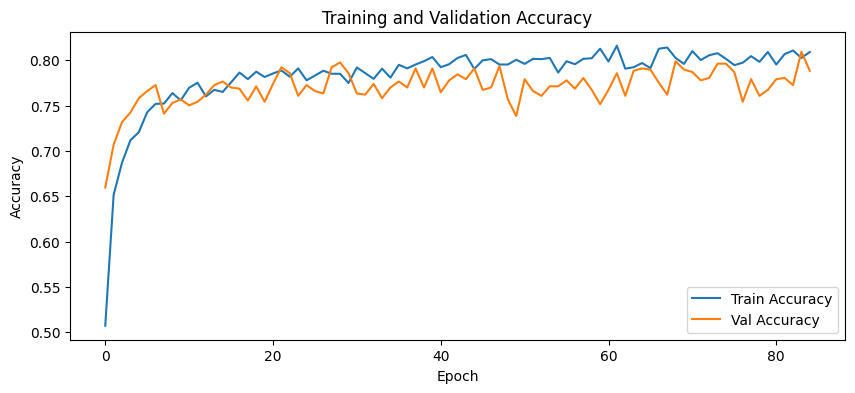

In [9]:
# Train the networks for at least 50 epochs (preferably 100 epochs) and perform
# early stopping using the validation set. Use a randomly selected subset of 20%
# of each class as the validation set. Keep the network parameters that have
# the lowest validation error. Plot the training and validation errors vs. epochs.

from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint


# Custom EarlyStopping that only activates after 50 epochs
class DelayedEarlyStopping(EarlyStopping):
   def __init__(self, min_epoch=50, **kwargs):
       super().__init__(**kwargs)
       self.min_epoch = min_epoch


   def on_epoch_end(self, epoch, logs=None):
       if epoch >= self.min_epoch:
           super().on_epoch_end(epoch, logs)
       else:
           # Reset the best weights until min_epoch is reached
           self.wait = 0
           self.stopped_epoch = 0


# Build your model
model = build_model()


# Define callbacks
callbacks = [
   DelayedEarlyStopping(
       monitor='val_loss',
       patience=10,
       restore_best_weights=True,
       min_epoch=50  # Delay early stopping until after epoch 50
   ),
   ModelCheckpoint("best_model_resnet50.h5", save_best_only=True)
]


# Train for up to 100 epochs
history = model.fit(
   train_aug.flow(X_train, y_train, batch_size=15),
   validation_data=val_aug.flow(X_val, y_val),
   epochs=100,                      # Preferable 100 epochs
   callbacks=callbacks
)

# Plot training and validation loss

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [10]:
# Report training, validation, and test Precision, Recall, AUC, and F1 score for
# those models. Is there a model that clearly outperforms others? Remember
# that this is a multi-class classification problem.

# Predict class probabilities and labels
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# Classification metrics
print("Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=class_names))

# AUC score
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print("AUC Score (macro-average):", auc_score)

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 257ms/step
Classification Report (Test Set):
                       precision    recall  f1-score   support

          1-Cardboard       0.73      0.90      0.81        92
      2-Food Organics       0.90      0.79      0.84        82
              3-Glass       0.77      0.75      0.76        84
              4-Metal       0.66      0.87      0.75       158
5-Miscellaneous Trash       0.70      0.58      0.63        99
              6-Paper       0.90      0.73      0.81       100
            7-Plastic       0.81      0.65      0.72       185
      8-Textile Trash       0.72      0.75      0.73        64
         9-Vegetation       0.88      0.99      0.93        87

             accuracy                           0.77       951
            macro avg       0.79      0.78      0.78       951
         weighted avg       0.78      0.77      0.77       951

AUC Score (macro-average): 0.974275387733372
